In [15]:
from macrodata_tools.data import get_cpi, compute_inflation
import matplotlib.pyplot as plt

In [16]:
cpi = get_cpi()
inflation = compute_inflation(cpi)

inflation = inflation.dropna()

inflation.head()

,Inflation
DATE,
2001-01-01,3.721205
2001-02-01,3.529412
2001-03-01,2.982456
2001-04-01,3.218256
2001-05-01,3.563084


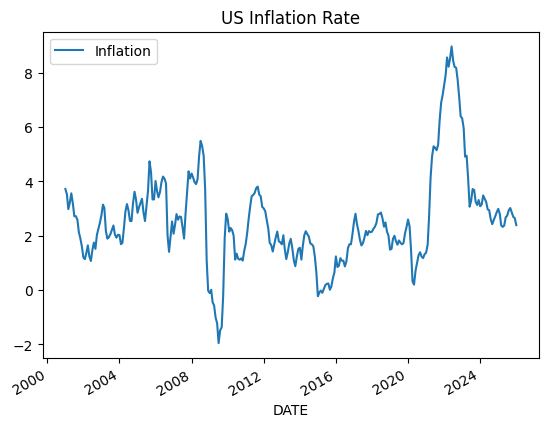

In [17]:
inflation.plot(title="US Inflation Rate")
plt.show()

## Data Cleaning
Remove missing values and inspect structure

In [18]:
inflation = inflation.dropna()

print(inflation.head())
print(inflation.info())

            Inflation
DATE                 
2001-01-01   3.721205
2001-02-01   3.529412
2001-03-01   2.982456
2001-04-01   3.218256
2001-05-01   3.563084
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 300 entries, 2001-01-01 to 2026-01-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Inflation  300 non-null    float64
dtypes: float64(1)
memory usage: 4.7 KB
None


## Descriptive Statistics
Summary statistics of inflation

In [19]:
inflation.describe()

,Inflation
count,300.000000
mean,2.551079
std,1.756040
min,-1.958761
25%,1.608073
50%,2.305234
75%,3.197181
max,8.979361


In [20]:
import numpy as np

mean_inflation = np.mean(inflation["Inflation"])
std_inflation = np.std(inflation["Inflation"])

print("Mean inflation:", mean_inflation)
print("Std inflation:", std_inflation)

Mean inflation: 2.5510787969677047
Std inflation: 1.7531112163122664


Rolling Inflation

In [21]:
inflation["Rolling_12M"] = inflation["Inflation"].rolling(window=12).mean()

inflation.head()

,Inflation,Rolling_12M
DATE,,
2001-01-01,3.721205,NaN
2001-02-01,3.529412,NaN
2001-03-01,2.982456,NaN
2001-04-01,3.218256,NaN
2001-05-01,3.563084,NaN


In [22]:
import seaborn as sns

Distribution of Inflation

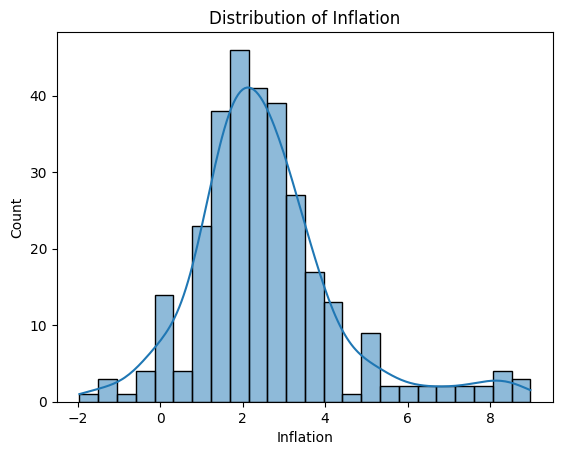

In [23]:
sns.histplot(inflation["Inflation"], kde=True)
plt.title("Distribution of Inflation")
plt.show()

Time Series Visualization

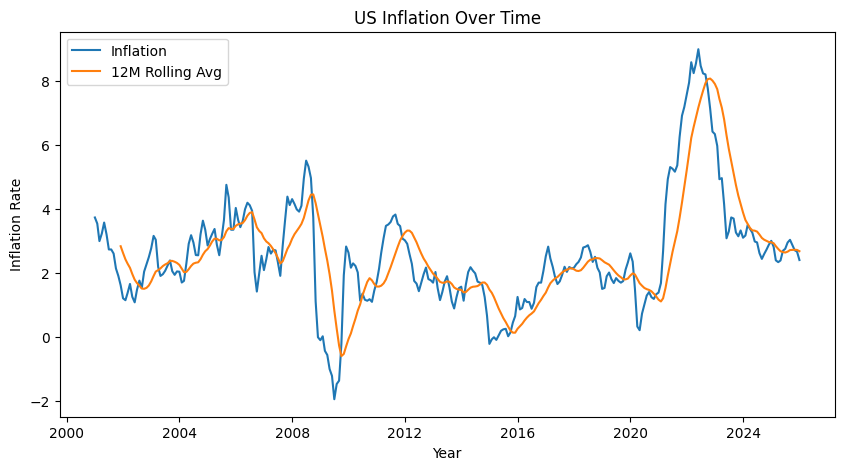

In [24]:
plt.figure(figsize=(10,5))

sns.lineplot(data=inflation, x=inflation.index, y="Inflation", label="Inflation")

sns.lineplot(data=inflation, x=inflation.index, y="Rolling_12M", label="12M Rolling Avg")

plt.title("US Inflation Over Time")
plt.xlabel("Year")
plt.ylabel("Inflation Rate")
plt.show()

Identify High Inflation Periods

In [25]:
inflation["High_Inflation"] = inflation["Inflation"] > 5

inflation[inflation["High_Inflation"]].head()

,Inflation,Rolling_12M,High_Inflation
DATE,,,
2008-07-01,5.497512,3.971855,True
2008-08-01,5.308017,4.256070,True
2021-06-01,5.295633,2.287830,True
2021-07-01,5.245169,2.641855,True
2021-08-01,5.152015,2.964434,True


Yearly Inflation Analysis

In [26]:
yearly_inflation = inflation.resample("Y").mean()

yearly_inflation.head()

/var/folders/wc/8crrf1850ldfb665mjgpqvww0000gn/T/ipykernel_7809/1532711561.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_inflation = inflation.resample("Y").mean()


,Inflation,Rolling_12M,High_Inflation
DATE,,,
2001-12-31,2.822434,2.822434,0.0
2002-12-31,1.594922,1.878964,0.0
2003-12-31,2.300187,2.163769,0.0
2004-12-31,2.666153,2.270353,0.0
2005-12-31,3.363332,3.100119,0.0


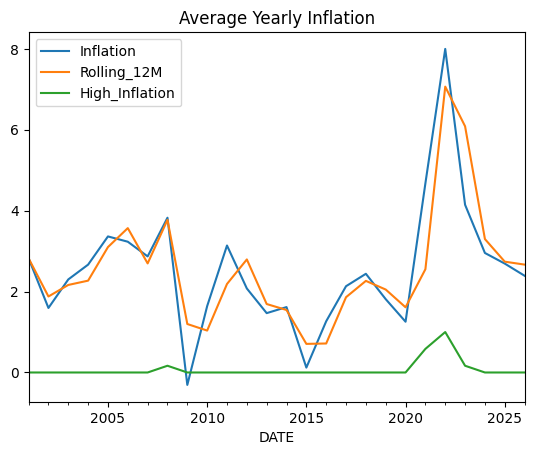

In [27]:
yearly_inflation.plot(title="Average Yearly Inflation")
plt.show()